In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [17]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

X = (X / 255.0) * 2 - 1

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)
#X_train = X[:60000]
#X_test = X[60000:]
#y_train = y[:60000]
#y_test = y[60000:]

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0) + 1e-8
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [23]:
learning_rate = 0.0005
epochs = 750
n_features = X_train.shape[1]

weights = []
biases = []
losses_all = []

In [25]:
for digit in range(10):
    print(f"Uczenie cyfry {digit}")

    w = np.random.normal(0, 0.001, n_features)
    b = np.random.normal(0, 0.001)

    y_binary = np.where(y_train == digit, 1.0, -1.0)

    losses = []

    for epoch in range(epochs):
        output = np.dot(X_train, w) + b

        error = y_binary - output

        w += learning_rate * np.dot(X_train.T, error) / len(X_train)
        b += learning_rate * np.mean(error)

        mse = np.mean(error ** 2)
        losses.append(mse)

    weights.append(w)
    biases.append(b)
    losses_all.append(losses)

Uczenie cyfry 0
Uczenie cyfry 1
Uczenie cyfry 2
Uczenie cyfry 3
Uczenie cyfry 4
Uczenie cyfry 5
Uczenie cyfry 6
Uczenie cyfry 7
Uczenie cyfry 8
Uczenie cyfry 9


In [27]:
outputs = []

for i in range(10):
    out = np.dot(X_test, weights[i]) + biases[i]
    outputs.append(out)

outputs = np.array(outputs).T

y_pred = np.argmax(outputs, axis=1)

error_rate = np.mean(y_pred != y_test)
accuracy = 1 - error_rate

print(f"Celność: {accuracy * 100:.2f}%")
print(f"Błąd testowy: {error_rate * 100:.2f}%")

Celność: 85.18%
Błąd testowy: 14.82%


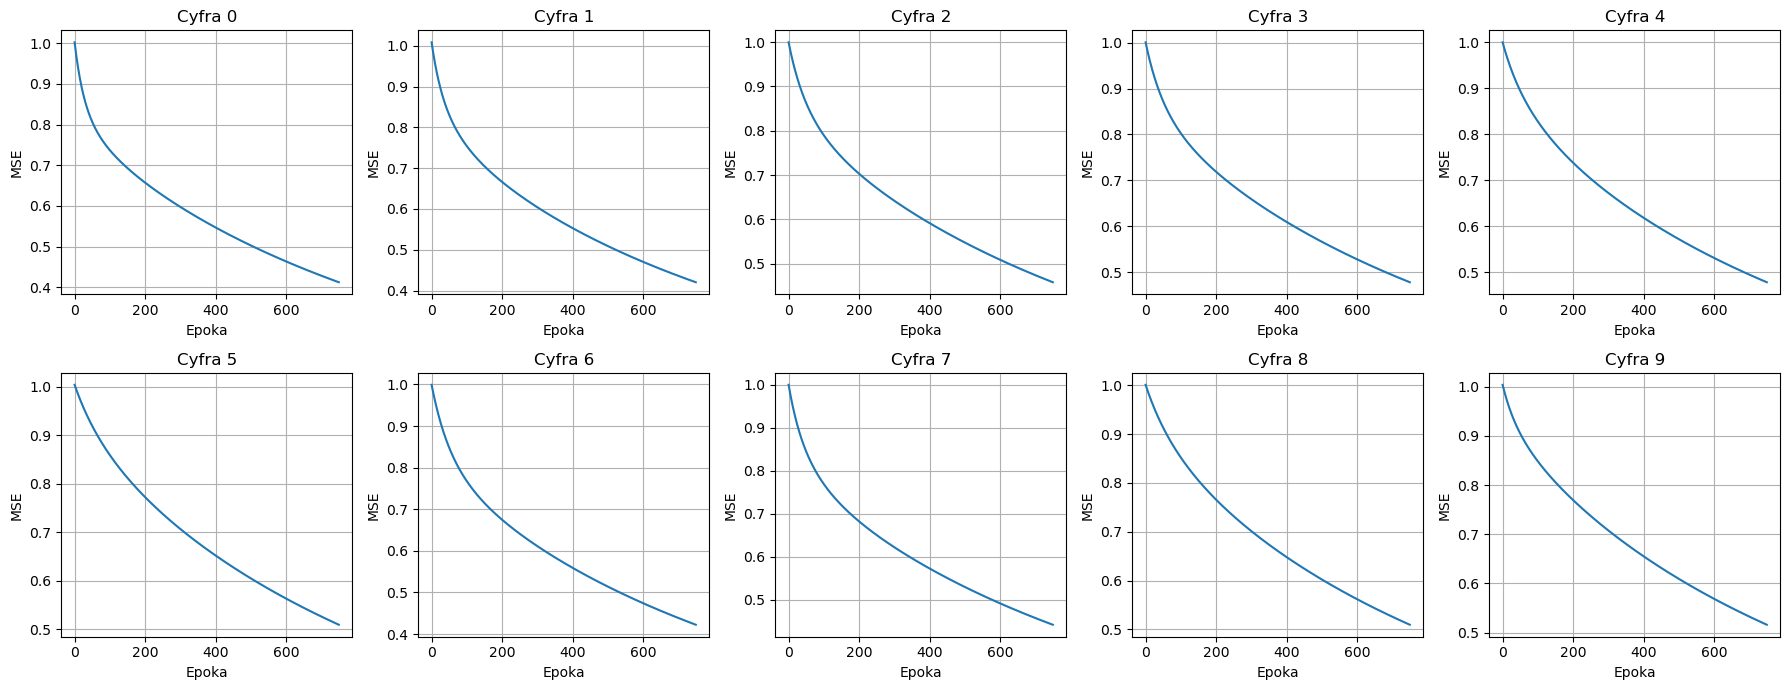

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for i in range(10):
    axes[i].plot(losses_all[i])
    axes[i].set_title(f"Cyfra {i}")
    axes[i].set_xlabel("Epoka")
    axes[i].set_ylabel("MSE")
    axes[i].grid(True)

plt.tight_layout()
plt.show()